# Stochastic subgradient descent

## Part 1: Algorithm implementation

Here we try to define the problem:

Given a RV si follow a distribution with probability P over Si, find the minimal x* in X for the Expectation of function f: X x Si -> R

## Approach:

Generate family of affine

In [309]:
from typing import List

L = 10 # Lipschitz constant
d = 10 # dimension of X
M = 10 # Number of affine in each realization


In [310]:
import numpy as np

class Realization:
    """Realization of f given fixed rv"""
    def __init__(self, M: int, d: int, L: float):
        # Local metadata
        self.M = M
        self.d = d
        self.L = L
        
        sd = 10
        
        # set function weights 
        self._weights = np.random.normal(0, sd, size=(M, d))
        self._bias = np.random.normal(0, sd, size=(M,))
        # self.init_weights()
        
       
    def __call__(self, x: np.ndarray):
        """evaluate f(x)"""
        assert x.shape[0] == self.d, print(f"Invalid dimension: {x.shape}, d: {self.d}")
        values = (self._weights @ x) + self._bias
        return np.max(values)
    
    def subgrad(self, x: np.ndarray):
        assert x.shape[0] == self.d, print(f"Invalid dimension: {x.shape}, d: {self.d}")
        
        values = (self._weights @ x) + self._bias
        max_val = max(values)
        # tolerance matching
        is_active = np.isclose(values, max_val, atol=1e-9)
        active_weights = self._weights[is_active]
        active_count = len(active_weights)
        
        # If only one affine is active, return that as grad
        if active_count == 1:
            return active_weights[0]
        
        # In case of more than one active count
        # get some affine combination of all grad
        # Shape: k,d.T @ k, => d,
        lambdas = np.random.dirichlet([1.0] * active_count)
        return active_weights.T @ lambdas
    



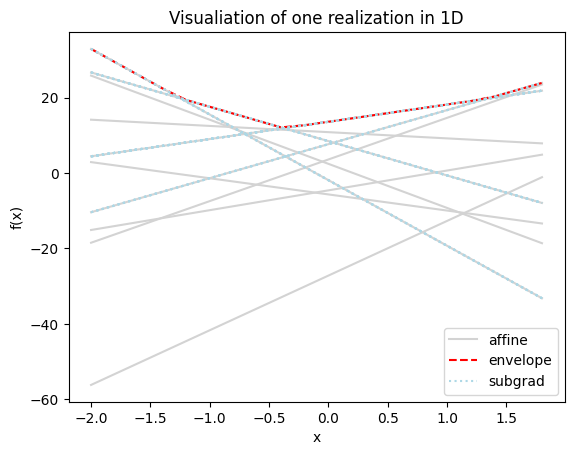

In [311]:
import matplotlib.pyplot as plt

## As a sample, we show graph with d=1
realization1 = Realization(M, 1, L)

# Plot the affine functions
weights = realization1._weights
bias = realization1._bias
x = np.arange(-2, 2, 0.2)
for i, (a, b) in enumerate(zip(weights, bias)):
    y = [a*x_i + b for x_i in x]
    label = "affine" if i == 0 else ""
    plt.plot(x, y, color="lightgrey", label=label)
    

# Plot the convex envelop
fx = [realization1(np.array([x_i])) for x_i in x]
plt.plot(x, fx, color="red", linestyle="--", label="envelope")

# Test subgradient
# NOTE: It is quite rare for the point to directly coincide with intersections 
# (where gradient become subgradient)
# We can randomize more attempts to get the extra line
for i, x_i in enumerate(x):
    x_pt = np.array([x_i])
    f_x = realization1(x_pt)
    subgrad = realization1.subgrad(x_pt)
    y_support = subgrad * (x - x_i) + f_x
    label = "subgrad" if i == 0 else ""
    plt.plot(x, y_support, color='lightblue', linestyle="dotted", label=label)
    
 
# Styling
plt.title("Visualiation of one realization in 1D")
plt.ylabel("f(x)")
plt.xlabel("x")
plt.legend()

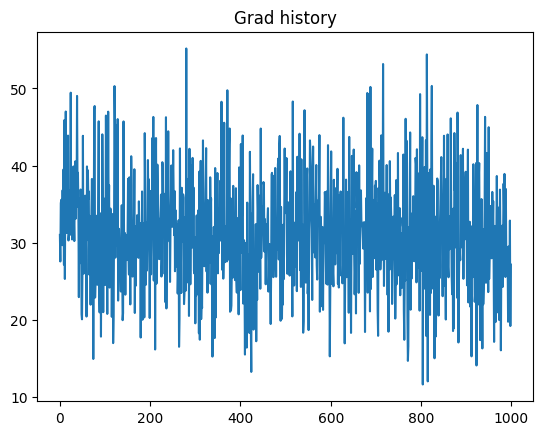

In [312]:
# Subgradient Descent loop
tolerance = 1e-5
T = 1000
x = np.random.rand(d)
grad_hist = []
x_hist = []
realization_hist: List[Realization] = []

def lr(t: int):
    return 1/ (t+1)

for t in range(T):
    # Generate a new realization each step
    realization = Realization(M, d, L)
    realization_hist.append(realization)
    
    # Compute subgradient at current x
    g = realization.subgrad(x)
    
    # Store for monitoring
    grad_norm = np.linalg.norm(g)
    grad_hist.append(grad_norm)
    
    # Update step
    x = x - lr(t) * g
    
    x_hist.append(x)
    
    if grad_norm < tolerance:
        break
    
    
# Plot grad_hist
plt.title("Grad history")
plt.plot(grad_hist)
plt.show()
plt.close()


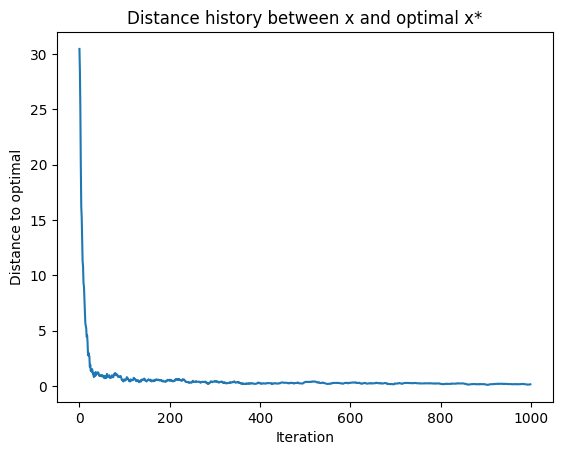

In [313]:
import cvxpy as cp

# Define optimization variable
x_opt = cp.Variable(d)

# Create auxiliary variables for each realization's max function
num_realizations = len(realization_hist)
t_vars = []  # t_i represents max of affine functions in realization i

constraints = []

for realization in realization_hist:
    t = cp.Variable()  # Auxiliary variable for this realization
    t_vars.append(t)
    
    # Constraint: t >= w_i^T x + b_i for all affine functions
    for w, b in zip(realization._weights, realization._bias):
        constraints.append(t >= w @ x_opt + b)

# Minimize the average of all t variables
objective = cp.sum(t_vars) / num_realizations
problem = cp.Problem(cp.Minimize(objective), constraints)
problem.solve()

x_true_optimal = x_opt.value

# Plot distance from optimal
dist_hist = [
    np.linalg.norm(x_i - x_true_optimal) for x_i in x_hist
]
plt.plot(dist_hist)
plt.title("Distance history between x and optimal x*")
plt.xlabel("Iteration")
plt.ylabel("Distance to optimal")
plt.show()